In [39]:
"""
Author: Peratham Wiriyathammabhum


"""
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
# import scipy.sparse.linalg as linalg
from numpy import linalg as LA
from scipy import linalg as SLA

# Import the libraries
# from sklearn.cross_decomposition import CCA

In [2]:
np.random.seed(0)

# Generate X and Y 100 instances with 10 dimensions each
X = np.random.randn(100, 10)
Y = X + np.random.randn(100, 10)	

In [3]:
ni, nd = X.shape

# centering
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
Y = (Y - np.mean(Y, axis=0)) / np.std(Y, axis=0)

In [4]:
# cross correlation
B = np.dot(X.T, Y)

In [5]:
B.shape

(10, 10)

In [14]:
# eigen decomposition
u, s, v = LA.svd(B)
ind = np.argsort(s, axis=0) # sorting descending
v = v[ind]
u = u[:, ind]

# create coordinate matrix
proj_v = v[:,0:2] # projection matrix
proj_u = u[:,0:2] # projection matrix
X_r = np.matmul(X, proj_u)
Y_r = np.matmul(Y, proj_v)

In [15]:
X_r.shape

(100, 2)

In [16]:
Y_r.shape

(100, 2)

In [17]:
u.shape

(10, 10)

In [18]:
s

array([115.11593003, 101.15589965,  87.30288501,  82.49878237,
        74.19844905,  65.3630387 ,  56.73909993,  51.09943204,
        44.61321414,  35.71490705])

In [19]:
ind = np.argsort(s, axis=0) # sorting descending


In [20]:
ind

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [21]:
ind

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

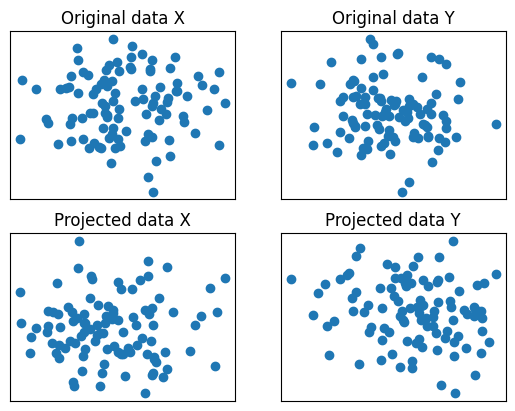

In [33]:
# plot
fig = plt.figure()

ax = fig.add_subplot(221)
ax.scatter(X[:, 0], X[:, 1])
ax.set_title("Original data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(222)
ax.scatter(Y[:, 0], Y[:, 1])
ax.set_title("Original data Y")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(223)
ax.scatter(X_r[:, 0], X_r[:, 1])
ax.set_title("Projected data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(224)
ax.scatter(Y_r[:, 0], Y_r[:, 1])
ax.set_title("Projected data Y")
plt.xticks([]), plt.yticks([])

# plt.axis('tight')
# plt.title('Projected data')
plt.show()

In [34]:
# cross correlation
Cxy = np.dot(X.T, Y)
Cxx = np.dot(X.T, X)
Cyx = np.dot(Y.T, X)
Cyy = np.dot(Y.T, Y)

In [36]:
Cxy.shape

(10, 10)

In [46]:
# eigen decomposition
A = np.dot(LA.pinv(Cyy, hermitian=True), Cyx)
A = np.dot(Cxy, A)
B = Cxx
sx, ux = SLA.eig(A, b=B)

In [47]:
A = np.dot(LA.pinv(Cxx, hermitian=True), Cxy)
A = np.dot(Cyx, A)
B = Cyy
sy, uy = SLA.eig(A, b=B)

In [50]:
ind = np.argsort(sx, axis=0) # sorting descending
ux = ux[:, ind]
ind = np.argsort(sy, axis=0) # sorting descending
uy = uy[:, ind]

In [52]:
# create coordinate matrix
proj_ux = ux[:,0:2] # projection matrix
proj_uy = uy[:,0:2] # projection matrix
X_r = np.matmul(X, proj_ux)
Y_r = np.matmul(Y, proj_uy)

In [53]:
ind

array([0, 9, 6, 8, 7, 5, 4, 3, 2, 1])

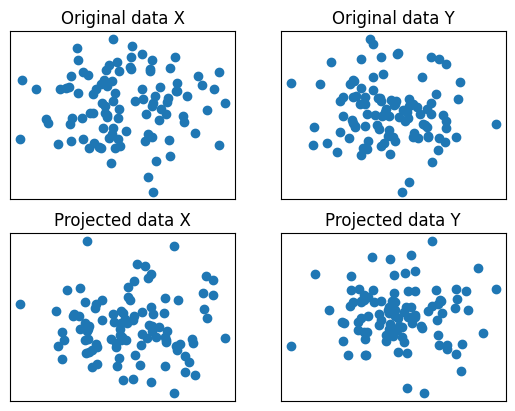

In [54]:
# plot
fig = plt.figure()

ax = fig.add_subplot(221)
ax.scatter(X[:, 0], X[:, 1])
ax.set_title("Original data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(222)
ax.scatter(Y[:, 0], Y[:, 1])
ax.set_title("Original data Y")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(223)
ax.scatter(X_r[:, 0], X_r[:, 1])
ax.set_title("Projected data X")
plt.xticks([]), plt.yticks([])

ax = fig.add_subplot(224)
ax.scatter(Y_r[:, 0], Y_r[:, 1])
ax.set_title("Projected data Y")
plt.xticks([]), plt.yticks([])

# plt.axis('tight')
# plt.title('Projected data')
plt.show()

In [57]:
LA.norm(ux, ord=2, axis=0,)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [58]:
LA.norm(u, ord=2, axis=0,)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [60]:
# correlation scores
score = X_r.T @ Y_r

In [69]:
np.sum(np.abs(score[:]))/len(score[:].flatten())

np.float64(20.76411815929046)

In [70]:
score

array([[ 3.69589889e+01, -1.14284005e-13],
       [-9.16142300e-14, -4.60974838e+01]])

In [80]:
# correlation scores
score = X_r.T @ Y_r
corr_score = np.sum(np.abs(score[:]))/len(score[:].flatten())
print("Correlation score: {:0.4f}".format(corr_score))

Correlation score: 20.7641
